In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1.0 Read JSON
This section reads the GeoJSON-style files in the `data/` folder (`locations (2).json` and `roadSegments (2).json`) and loads them into pandas and GeoPandas for analysis.

In [2]:
from pathlib import Path
import json
import geopandas as gpd
from shapely.geometry import Point, LineString

# Paths (notebook is in `notebooks/`)
DATA_DIR = Path('..') / 'data'
LOC_FP = DATA_DIR / 'locations (2).json'
ROAD_FP = DATA_DIR / 'roadSegments (2).json'

assert LOC_FP.exists(), f"Missing: {LOC_FP}"
assert ROAD_FP.exists(), f"Missing: {ROAD_FP}"

def load_geojson_features(fp):
    with open(fp, 'r', encoding='utf-8') as fh:
        obj = json.load(fh)
    return obj.get('features', [])

loc_features = load_geojson_features(LOC_FP)
road_features = load_geojson_features(ROAD_FP)

print('locations features:', len(loc_features))
print('roadSegments features:', len(road_features))

locations features: 20829
roadSegments features: 1960


In [3]:
# Create pandas DataFrames from the features; keep nested properties flattened for analysis.
# For locations we extract properties + coordinates; for road segments we extract properties + coordinate lists.
def features_to_df(features):
    # properties may be missing keys across features; json_normalize handles this reasonably
    rows = []
    for f in features:
        props = f.get('properties', {}).copy()
        # bring some top-level fields into the row (id, road_id, region_id)
        props['_id'] = f.get('_id')
        props['road_id'] = f.get('road_id')
        props['region_id'] = f.get('region_id')
        geom = f.get('geometry') or {}
        props['geometry_type'] = geom.get('type')
        props['geometry_coords'] = geom.get('coordinates')
        rows.append(props)
    return pd.DataFrame(rows)

df_loc = features_to_df(loc_features)
df_road = features_to_df(road_features)

# For locations, split coords into lon/lat if available
if 'geometry_coords' in df_loc.columns:
    df_loc['lon'] = df_loc['geometry_coords'].apply(lambda c: c[0] if isinstance(c, (list, tuple)) and len(c) >= 2 else None)
    df_loc['lat'] = df_loc['geometry_coords'].apply(lambda c: c[1] if isinstance(c, (list, tuple)) and len(c) >= 2 else None)

# For roads we leave the coordinate lists as-is, but we can get segment length from properties if present
display_cols = ['_id','road_id','region_id','geometry_type']
print('locations DataFrame shape:', df_loc.shape)
print('roadSegments DataFrame shape:', df_road.shape)
df_loc.head(3)[display_cols + ['lon','lat']]

locations DataFrame shape: (20829, 13)
roadSegments DataFrame shape: (1960, 45)


,_id,road_id,region_id,geometry_type,lon,lat
0,68d703342294ad50adb9ebbf,68d703332294ad50adb9eaa8,usa_georgia_peachtree-corners,Point,-84.225030,33.961139
1,68d703342294ad50adb9ebc0,68d703332294ad50adb9eaa8,usa_georgia_peachtree-corners,Point,-84.225179,33.961143
2,68d703342294ad50adb9ebc1,68d703332294ad50adb9eaa8,usa_georgia_peachtree-corners,Point,-84.225328,33.961179


In [4]:
# Convert to GeoDataFrames
# locations -> points
loc_gdf = gpd.GeoDataFrame(df_loc.copy(), geometry=[Point(xy) if xy is not None else None for xy in df_loc['geometry_coords'].apply(lambda c: (c[0], c[1]) if isinstance(c, (list,tuple)) and len(c)>=2 else None)])
loc_gdf.set_crs('EPSG:4326', inplace=True)
print('Converted locations to GeoDataFrame, crs=', loc_gdf.crs)

# road segments -> LineString geometries when possible
def coords_to_linestring(coords):
    try:
        return LineString(coords)
    except Exception:
        return None

road_geom = df_road['geometry_coords'].apply(lambda c: coords_to_linestring(c) if isinstance(c, list) else None)
road_gdf = gpd.GeoDataFrame(df_road.copy(), geometry=road_geom)
road_gdf.set_crs('EPSG:4326', inplace=True)
print('Converted roadSegments to GeoDataFrame, sample:')
display(road_gdf.head(2))

Converted locations to GeoDataFrame, crs= EPSG:4326
Converted roadSegments to GeoDataFrame, sample:


,name,centerline_id,speed_limit,FROMLEFT,TOLEFT,FROMRIGHT,TORIGHT,FEDROUTE,FEDRTETYPE,STROUTE,...,osmid,_id,road_id,region_id,geometry_type,geometry_coords,pci,pci_category,raw_pci,geometry
0,RIVER TRAIL DR,223312,25,4430,4458,4431,4459,None,None,None,...,1000,68d703322294ad50adb9e3ff,None,usa_georgia_peachtree-corners,LineString,"[[-84.22776889587401, 34.00224609386214], [-84...",NaN,NaN,NaN,"LINESTRING (-84.22777 34.00225, -84.22777 34.0..."
1,PEACHTREE INDUSTRIAL BLVD ACCESS RD,222121,55,6450,6458,0,0,None,None,None,...,1000,68d703322294ad50adb9e400,None,usa_georgia_peachtree-corners,LineString,"[[-84.2414262608243, 33.943113373539326], [-84...",82.0,Very Good,179.104604,"LINESTRING (-84.24143 33.94311, -84.24056 33.9..."


## 1.1 Location JSON

**Top-line summary**

| Metric | Value |
|---|---:|
| File size | 16.2 MB |
| Top-level structure | A single GeoJSON `FeatureCollection` |
| Feature count | **20,829** |
| Unique `_id` values | 20,829 (no dupes — every row is a unique image) |
| Unique `road_id` values | **1,468** (so 20k images map onto ~1.5k road segments) |
| Region | `usa_georgia_peachtree-corners` (all features) |
| Export timestamp | `2025-09-26T15:38:36` (one batch export) |

**What one row looks like**

Every feature is a single road image taken from a GoPro-style camera mounted on a vehicle.

```json
{
  "_id": "68d703342294ad50adb9ebbf",
  "type": "Feature",
  "properties": {
    "name": "GX010224_time_4_00250",
    "image_path": "session_1/05142025/peachtree_corners_GX010224-2025-06-10/GX010224_time_4_00250.jpg",
    "defects": { "transverse cracks": 1, "manhole covers": 1 },
    "type": "location",
    "details": [],
    "road_name": "ENGINEERING DR"
  },
  "geometry": {
    "type": "Point",
    "coordinates": [ -84.2250298889, 33.9611386944 ]
  },
  "road_id": "68d703332294ad50adb9eaa8",
  "region_id": "usa_georgia_peachtree-corners",
  "created_at": "2025-09-26T21:18:43.915000",
  "updated_at": "2025-09-26T21:18:43.915000"
}
```

### Field-by-field meaning

| Field | Type | What it means | Notes |
|---|---|---|---|
| `_id` | string | Mongo ObjectId for this image record | the *image's* primary key |
| `type` | string | Always `"Feature"` | required by GeoJSON spec |
| `properties.name` | string | Image base name, e.g. `GX010224_time_4_00250` | `GX######` is the GoPro source video; trailing `00250` is the frame number |
| `properties.image_path` | string | Relative path to the JPG on disk | format: `session_<N>/<MMDDYYYY>/peachtree_corners_<GoProID>-<upload_date>/<frame>.jpg` |
| `properties.defects` | dict | CV-detected defects in this single image, keyed by defect type, valued by **count** | `{}` means "nothing detected" — *not* "not yet scored" |
| `properties.type` | string | Always `"location"` | distinguishes from `roadSegments`'s `"road"` records |
| `properties.details` | list | **Always empty** — placeholder field, no data | NA |
| `properties.road_name` | string | Human-readable street name | **missing on 3,165 of 20,829 features** (15%) — images where road context wasn't resolved |
| `geometry.type` | string | Always `"Point"` | one image = one GPS point |
| `geometry.coordinates` | `[lon, lat]` | WGS84 (EPSG:4326) | longitude first, latitude second — GeoJSON convention |
| `road_id` | string | FK to a road segment in `roadSegments (2).json` (`_id`) | **the join key** |
| `region_id` | string | Always `usa_georgia_peachtree-corners` | every image is in this one city |
| `created_at` / `updated_at` | ISO datetime | When the DB record was written, not when the photo was taken | every record has the same date — single export batch |

### 1.1.1 Defects

Sparse dict: keys appear only if that defect type was detected. Counts are integers (how many of that defect were found in the image).

Distribution across all 20,829 images:

| Defect type | Total occurrences | Rough interpretation |
|---|---:|---|
| longitudinal cracks | 29,277 | Cracks parallel to direction of travel |
| transverse cracks | 18,760 | Cracks perpendicular to direction of travel |
| block cracks | 3,709 | Interconnected cracks dividing pavement into rectangles |
| alligator cracks | 2,812 | Interconnected cracks resembling alligator skin (load-related, structural) |
| manhole covers | 1,286 | Not a defect; asset detection |
| potholes | 604 | Classic pothole |
| patching | 28 | Patches (prior repairs) — itself a feature, not a defect |
| repaired cracks | 11 | Sealed/filled cracks |
| sealing | 1 | Seal coat |

Per-image stats:

| Stat | Value |
|---|---:|
| Images with **zero** defects detected | **3,406** (16.4%) |
| Mean # of *defect types* per image | 1.41 |
| Mean # of *total defect instances* per image | 2.71 |
| Max defects in a single image | 26 |

In [5]:
# Summary statistics: counts of defect types (from properties) for locations
from collections import Counter

defect_counts = Counter()
for d in df_loc.get('defects', []):
    if isinstance(d, dict):
        defect_counts.update(d)

# Convert Counter to DataFrame and add percentages
total = sum(defect_counts.values())
if total > 0:
    defect_df = pd.DataFrame(defect_counts.items(), columns=['defect','count'])
    defect_df = defect_df.sort_values('count', ascending=False).reset_index(drop=True)
    defect_df['pct'] = (defect_df['count'] / total * 100).round(2)
else:
    defect_df = pd.DataFrame(columns=['defect','count','pct'])

print('Sample defect counts (locations):')
display(defect_df)


Sample defect counts (locations):


,defect,count,pct
0,longitudinal cracks,29277,51.83
1,transverse cracks,18760,33.21
2,block cracks,3709,6.57
3,alligator cracks,2812,4.98
4,manhole covers,1286,2.28
5,potholes,604,1.07
6,patching,28,0.05
7,repaired cracks,11,0.02
8,sealing,1,0.00


In [6]:
# Images / defect-summary (assumes `df_loc` present and `defects` is a dict per row)

defects = df_loc['defects'].apply(lambda d: d if isinstance(d, dict) else {})

# per-image metrics
df_loc['defect_types_count'] = defects.apply(lambda d: sum(1 for v in d.values() if isinstance(v, (int, float)) and v > 0))
df_loc['defect_instances'] = defects.apply(lambda d: sum(v for v in d.values() if isinstance(v, (int, float))))

# summary values
total_images = len(df_loc)
zero_defect_images = int((df_loc['defect_instances'] == 0).sum())
pct_zero = zero_defect_images / total_images * 100
mean_types = df_loc['defect_types_count'].mean()
mean_instances = df_loc['defect_instances'].mean()
max_defects_single = int(df_loc['defect_instances'].max())

# present results
summary = {
    'zero_defect_images': f'{zero_defect_images} ({pct_zero:.1f}%)',
    'mean_defect_types_per_image': round(mean_types, 2),
    'mean_total_defect_instances_per_image': round(mean_instances, 2),
    'max_defects_in_single_image': max_defects_single
}
pd.Series(summary)

zero_defect_images                       3406 (16.4%)
mean_defect_types_per_image                      1.41
mean_total_defect_instances_per_image            2.71
max_defects_in_single_image                        26
dtype: object

### 1.1.2 Road ID

**Missing on 3,165 images.** When aggregating defects by road, decide up front whether to drop these or back-fill via the joined `roadSegments` record (through `road_id`).

Number of unique `road_id` is identical to the 1,467 `"scanned"` segments in `roadSegments (2).json`. So the file is functionally a **scan log of the segments PavePal has driven so far** — not the full network.

In [7]:
print("% missing:")
df_loc.road_id.isna().mean().round(3) * 100

% missing:


15.2

In [8]:
df_loc.road_id.nunique()

1467

### 1.1.3 Coordinates

Bounding box of all 20,829 GPS points:

| Field | Min | Max | Span |
|---|---|---|---|
| Longitude | -84.273036 | -84.159091 | ~10 km (east–west) |
| Latitude | 33.359410 | 34.002266 | **~71 km** (north–south) |

The east-west range matches Peachtree Corners' actual size. The **71 km north-south range looks wrong** — the city is only ~6 km tall. The low-end latitude `33.36°` (roughly south of Atlanta proper) is almost certainly a handful of bad GPS readings or transit shots. **Plan to filter outliers before plotting.**

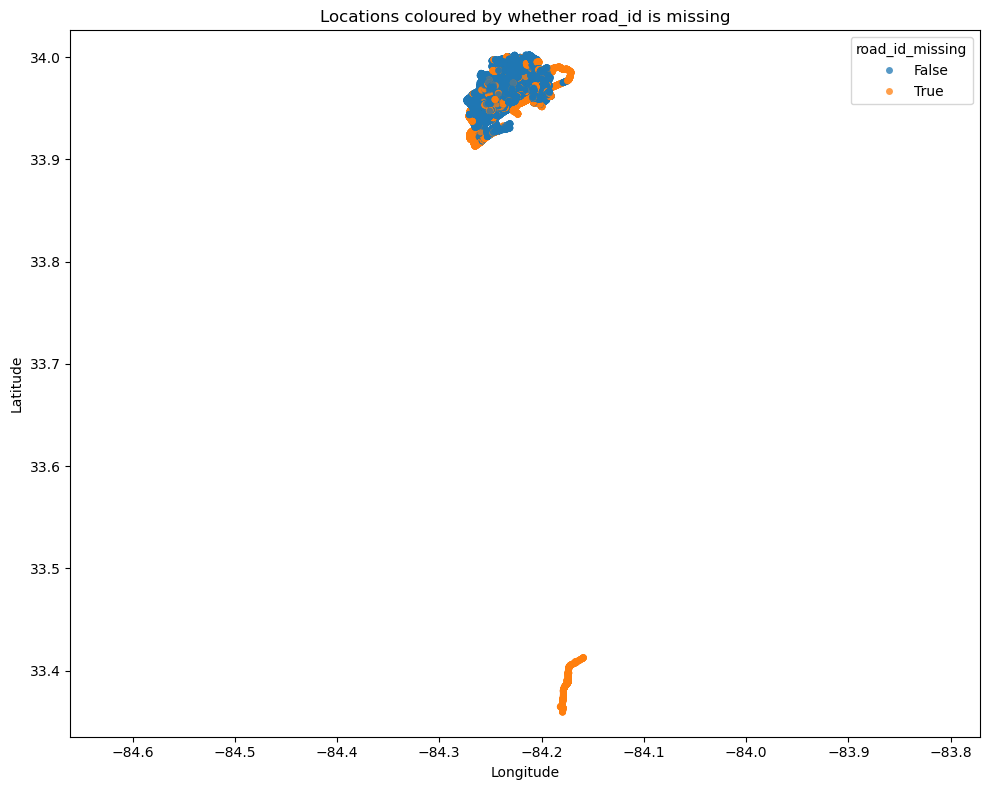

In [9]:
plot_df = df_loc.copy()
plot_df["road_id_missing"] = plot_df["road_id"].isna()

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=plot_df,
    x="lon",
    y="lat",
    hue="road_id_missing",
    s=25,
    alpha=0.75,
    linewidth=0,
    ax=ax,
)

ax.set_title("Locations coloured by whether road_id is missing")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

In [10]:
df_loc.query("lat < 33.5").defects

10031                                  {'block cracks': 1}
10032                              {'alligator cracks': 2}
10033                              {'alligator cracks': 1}
10034                           {'longitudinal cracks': 1}
10035                             {'transverse cracks': 1}
                               ...                        
13522                           {'longitudinal cracks': 1}
13523    {'transverse cracks': 3, 'longitudinal cracks'...
13524    {'transverse cracks': 4, 'longitudinal cracks'...
13525    {'longitudinal cracks': 2, 'transverse cracks'...
13526                           {'longitudinal cracks': 1}
Name: defects, Length: 509, dtype: object

## 1.2 Road segments

**Not a summary of `locations.json`.** This file is two things stitched together:
1. The **city of Peachtree Corners' road inventory** (1,960 segments handed to PavePal — including 493 segments PavePal has not driven yet).
2. **PavePal's scan results** layered on top of the 1,467 segments that have been driven.

The per-segment `defects` field *is* an exact rollup of per-image defects from `locations.json` — verified: 1,960/1,960 segments match the per-image sum perfectly. But the segment list itself, the geometry, and ~25 GIS attribute fields all came from the city before any scanning happened.

**Top-line summary**

| Metric | Value |
|---|---:|
| File size | 5.0 MB |
| Top-level structure | GeoJSON `FeatureCollection` of `LineString` features |
| Feature count | **1,960 segments** |
| Scanned by PavePal | **1,467** (75%) |
| Still scheduled | **493** (25%) |
| Total network length | 304.1 km |
| Region | `usa_georgia_peachtree-corners` |
| Source | `"city_provided"` (all 1,960) |
| Export timestamp | `2025-09-26T15:38:38` |

**What one row looks like — a scanned segment**

```json
{
  "_id": "68d703322294ad50adb9e400",
  "source": "city_provided",
  "type": "Feature",
  "properties": {
    "name": "PEACHTREE INDUSTRIAL BLVD ACCESS RD",
    "centerline_id": "222121",
    "speed_limit": 55,
    "ROADCLASS": "Major Arterial",
    "ONEWAYDIR": "To-From",
    "MUNILEFT": "NORCROSS", "MUNIRIGHT": "NORCROSS",
    "ZIPLEFT": "30071",     "ZIPRIGHT": "30071",
    "ESNLEFT": "196",       "ESNRIGHT": "196",
    "QUAD": "NW",
    "length_km": 0.0949,
    "scanned": "scanned",
    "defects": { "transverse cracks": 5, "longitudinal cracks": 12 },
    "pci": 82,
    "pci_category": "Very Good",
    "raw_pci": 179.10,
    "type": "road"
  },
  "geometry": { "type": "LineString", "coordinates": [[lon,lat], ...] }
}
```

### Field-by-field reference

**GeoJSON / DB wrapper**

| Field | Type | Meaning |
|---|---|---|
| `_id` | string | Mongo ObjectId — **the join target for `locations.json`'s `road_id`** |
| `source` | string | Always `"city_provided"` |
| `type` | string | Always `"Feature"` |
| `region_id` | string | Always `usa_georgia_peachtree-corners` |
| `created_at` / `updated_at` | ISO datetime | DB write time, not survey time |

**Layer A — the city's GIS / NG911 attributes (present on all 1,960)**

These are standard road-centerline / E-911 fields the city already maintained.

| Field | Meaning |
|---|---|
| `name` | Human street name, e.g. `PEACHTREE INDUSTRIAL BLVD ACCESS RD` |
| `centerline_id` | The **city's** segment ID (6-digit string, e.g. `"222121"`) — NOT the same as IMS's `GISID` |
| `STREETNAME` | An internal street code, e.g. `"RD-69088"` |
| `speed_limit` | mph |
| `ROADCLASS` | Functional class (see distribution below) |
| `ONEWAYDIR` | `null` (two-way), `From-To`, or `To-From`. Only ~12% are one-way |
| `FROMLEFT`, `TOLEFT`, `FROMRIGHT`, `TORIGHT` | Address number ranges on each side of the segment |
| `EVEN_HAND` | Which side has even-numbered addresses (`L` or `R`) |
| `OWNEDBY` / `MAINTBY` | Integer codes (1, 2, -1, -2) — owner/maintainer agency. **Not decoded in the file**; you'd need to ask PavePal or check the city's GIS schema |
| `MUNILEFT` / `MUNIRIGHT` | Municipality (city) on each side, e.g. `PEACHTREE CORNERS`, `NORCROSS` |
| `ZIPLEFT` / `ZIPRIGHT` | ZIP codes |
| `MSAGLEFT` / `MSAGRIGHT` | Master Street Address Guide name (911 dispatch) |
| `ESNLEFT` / `ESNRIGHT` | Emergency Service Number |
| `QUAD` | Quadrant (`NW`/`NE`/`SW`/`SE`) |
| `LAR`, `LAR_DIR` | Local Address Range / direction (sparse, ~12%) |
| `FEDROUTE`, `FEDRTETYPE`, `STROUTE`, `STRTETYPE` | Federal / state highway designations (mostly null) |
| `INWATER` | Always `"No"` |
| `ROADLEVEL` | Mostly 0 (surface); 13 segments are level 1 (likely bridge) |
| `ROW_WIDTH` | Right-of-way width — always 0.0 in this file (not populated) |
| `length` | Segment length in **metres** |
| `length_km` | Same in km |
| `osmid` | OpenStreetMap ID — but every record shows `1000`, so this looks like a placeholder, not real OSM data |

**Layer B — PavePal's scan layer (only on the 1,467 scanned)**

| Field | Meaning |
|---|---|
| `scanned` | `"scanned"` (1,467) or `"scheduled"` (493) |
| `defects` | Sparse dict, same defect taxonomy as `locations.json`. **Verified to equal exactly the sum of per-image defects across that segment's images.** Empty `{}` on 67 of the scanned segments (driven but no defects detected) |
| `pci` | The **displayed** Pavement Condition Index, integer 0–100 |
| `pci_category` | One of `"Excellent"`, `"Very Good"`, `"Good"`, `"Poor"` (no `"Fair"` or `"Marginal"` in this file) |
| `raw_pci` | A pre-clipped intermediate score. Range **0 to 368,922** — clearly *not* on a 0–100 scale. Median 258, mean 727. Looks like accumulated "deduct points" before normalisation. Treat `pci` as the canonical value and `raw_pci` as diagnostic |
| `type` | Always `"road"` (vs `"location"` in `locations.json`) |

In [11]:
# Missing values for columns with any missing values
road_gdf.filter(road_gdf.columns[road_gdf.isna().any()]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FEDROUTE      39 non-null     object 
 1   FEDRTETYPE    39 non-null     object 
 2   STROUTE       147 non-null    object 
 3   STRTETYPE     147 non-null    object 
 4   ONEWAYDIR     244 non-null    object 
 5   STREETNAME    1913 non-null   object 
 6   LAR_DIR       244 non-null    object 
 7   LAR           244 non-null    object 
 8   road_id       0 non-null      object 
 9   pci           1467 non-null   float64
 10  pci_category  1467 non-null   object 
 11  raw_pci       1467 non-null   float64
dtypes: float64(2), object(10)
memory usage: 183.9+ KB


### 1.2.1 Scanned

In [12]:
road_gdf.scanned.value_counts(dropna=False)

scanned
scanned      1467
scheduled     493
Name: count, dtype: int64

### 1.2.2 Defects

In [13]:
# Aggregate defects attached to road segments
road_defect_counts = Counter()
for d in road_gdf.get('defects', []):
    if isinstance(d, dict):
        road_defect_counts.update(d)

road_defect_df = pd.DataFrame(road_defect_counts.items(), columns=['defect','count']).sort_values('count', ascending=False).reset_index(drop=True)
road_defect_df['pct'] = (road_defect_df['count'] / total * 100).round(2)
print('\nTop defects on roadSegments:')
display(road_defect_df.head(10))



Top defects on roadSegments:


,defect,count,pct
0,longitudinal cracks,25639,45.39
1,transverse cracks,16423,29.07
2,block cracks,3387,6.00
3,alligator cracks,2308,4.09
4,manhole covers,1218,2.16
5,potholes,498,0.88
6,patching,20,0.04
7,repaired cracks,8,0.01
8,sealing,1,0.00


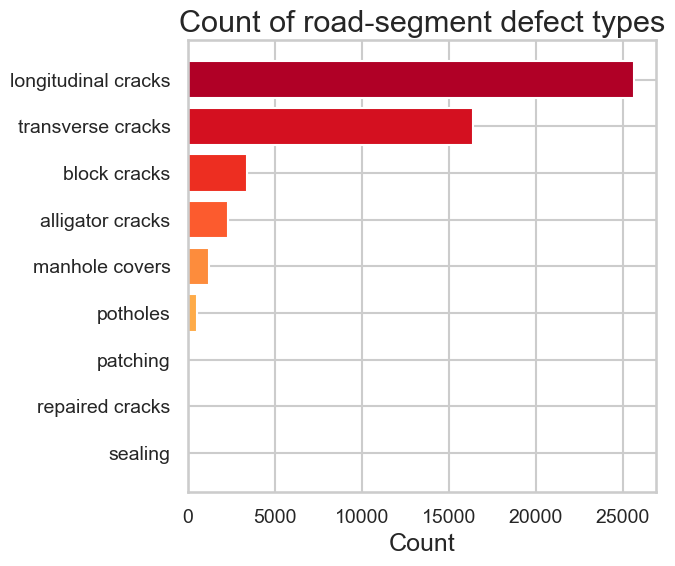

In [14]:
# Static bar chart of road-segment defect counts
sns.set(style="whitegrid")

# Plot top N defect types
top_n = 20
plot_df = road_defect_df.head(top_n).copy().iloc[::-1]  # reverse for horizontal ordering

plt.figure(figsize=(7, 6))
sns.set_context("talk", rc={
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
colors = sns.color_palette("YlOrRd", n_colors=len(plot_df))
plt.barh(plot_df['defect'], plot_df['count'], color=colors)
plt.xlabel("Count")
plt.title(f"Count of road-segment defect types")
plt.tight_layout()
plt.show()

In [15]:
# Road-segment defect summary (assumes `road_gdf` present and `defects` is a dict per row)

defects = road_gdf['defects'].apply(lambda d: d if isinstance(d, dict) else {})

# per-segment metrics
road_gdf['defect_types_count'] = defects.apply(lambda d: sum(1 for v in d.values() if isinstance(v, (int, float)) and v > 0))
road_gdf['defect_instances'] = defects.apply(lambda d: sum(v for v in d.values() if isinstance(v, (int, float))))

In [16]:
road_gdf.defect_types_count.describe().round(2)

count    1960.0
mean        2.2
std         1.8
min         0.0
25%         0.0
50%         2.0
75%         4.0
max         7.0
Name: defect_types_count, dtype: float64

In [17]:
road_gdf.defect_instances.describe().round(2)

count    1960.00
mean       25.26
std        41.22
min         0.00
25%         0.00
50%        10.00
75%        33.00
max       450.00
Name: defect_instances, dtype: float64

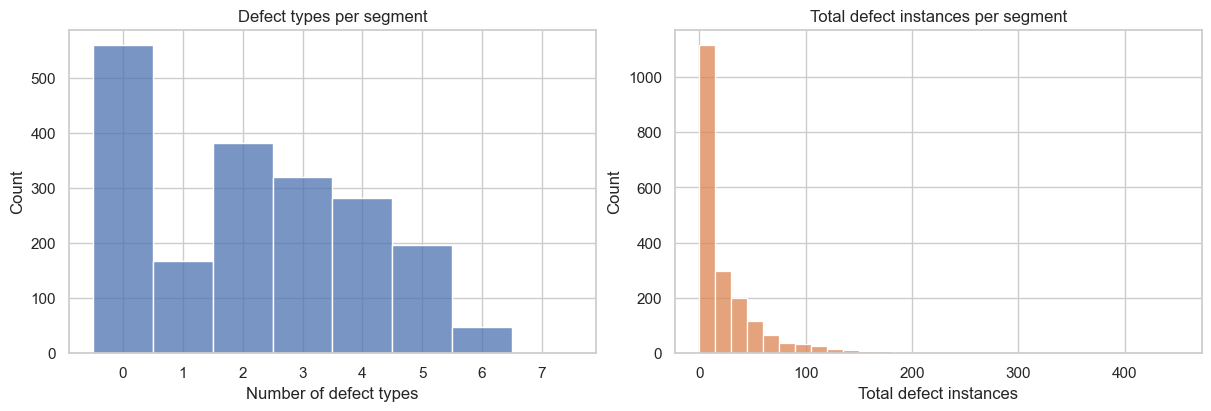

In [18]:
sns.set(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.histplot(road_gdf['defect_types_count'], bins=range(0, int(road_gdf['defect_types_count'].max()) + 2), discrete=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Defect types per segment')
axes[0].set_xlabel('Number of defect types')
axes[0].set_ylabel('Count')

sns.histplot(road_gdf['defect_instances'], bins=30, ax=axes[1], color='#DD8452')
axes[1].set_title('Total defect instances per segment')
axes[1].set_xlabel('Total defect instances')
axes[1].set_ylabel('Count')

plt.show()

### 1.2.3 PCI

PCI (across the 1,467 scanned)

| Stat | Value |
|---|---:|
| Mean | 70.7 |
| Median | 74 |
| Min | 0 |
| Max | 100 |

`pci_category`

| Category | Count |
|---|---:|
| Excellent | 435 |
| Very Good | 398 |
| Good | 370 |
| Poor | 264 |

C:\Users\liauw\AppData\Local\Temp\ipykernel_40000\2603715008.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


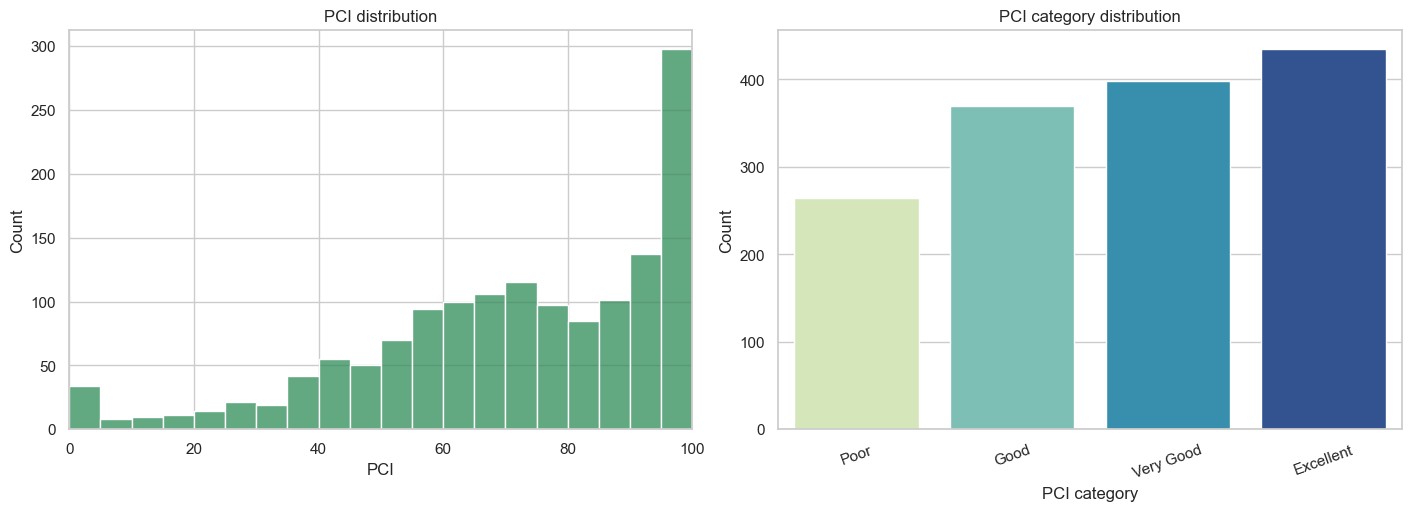

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pci_df = road_gdf[["pci", "pci_category"]].dropna(subset=["pci", "pci_category"]).copy()
pci_category_order = ["Poor", "Good", "Very Good", "Excellent"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.histplot(
    data=pci_df,
    x="pci",
    bins=20,
    binrange=(0, 100),
    color="#2E8B57",
    edgecolor="white",
    ax=axes[0],
)
axes[0].set_title("PCI distribution")
axes[0].set_xlabel("PCI")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 100)

sns.countplot(
    data=pci_df,
    x="pci_category",
    order=[cat for cat in pci_category_order if cat in pci_df["pci_category"].unique()],
    palette="YlGnBu",
    ax=axes[1],
)
axes[1].set_title("PCI category distribution")
axes[1].set_xlabel("PCI category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.show()

In [20]:
# Find actual pci cutoffs implied by existing pci_category labels
cutoffs = (
    road_gdf[["pci", "pci_category"]]
    .dropna(subset=["pci", "pci_category"])
    .groupby("pci_category")["pci"]
    .agg(["min", "max", "count"])
    .sort_values("min")
)

cutoffs

,min,max,count
pci_category,,,
Poor,0.0,49.0,264
Good,50.0,69.0,370
Very Good,70.0,89.0,398
Excellent,90.0,100.0,435


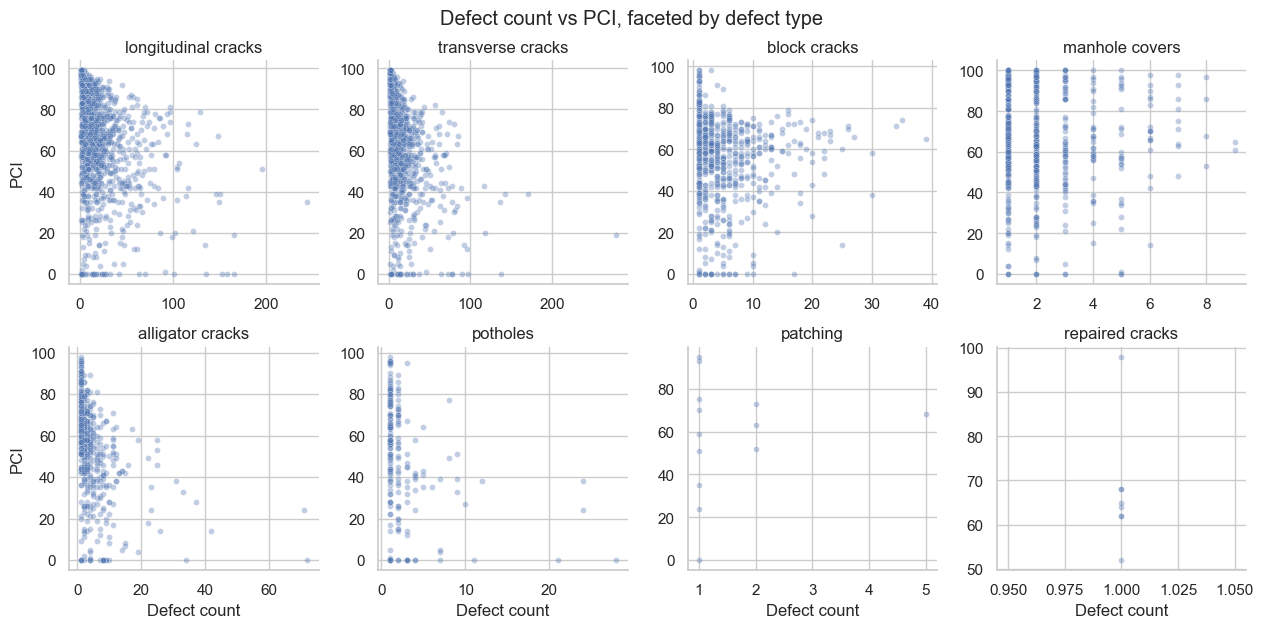

In [21]:
# Check if different defect types contribute differently to decreasing PCI
sns.set(style='whitegrid', context='notebook')

rows = []
for pci_value, defect_dict in zip(road_gdf['pci'], road_gdf['defects'].apply(lambda d: d if isinstance(d, dict) else {})):
    if pd.isna(pci_value):
        continue
    for defect_type, defect_count in defect_dict.items():
        if isinstance(defect_count, (int, float)) and defect_count > 0:
            rows.append({'pci': pci_value, 'defect_type': defect_type, 'defect_count': defect_count})

plot_df = pd.DataFrame(rows)
plot_df['defect_type'] = pd.Categorical(
    plot_df['defect_type'],
    categories=plot_df['defect_type'].value_counts().head(8).index,
    ordered=True,
)
plot_df = plot_df[plot_df['defect_type'].notna()]

g = sns.FacetGrid(plot_df, col='defect_type', col_wrap=4, sharex=False, sharey=False, height=3.2)
g.map_dataframe(sns.scatterplot, x='defect_count', y='pci', alpha=0.35, s=18, color='#4C72B0')
g.set_axis_labels('Defect count', 'PCI')
g.set_titles('{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Defect count vs PCI, faceted by defect type')
plt.show()

C:\Users\liauw\AppData\Local\Temp\ipykernel_40000\388632920.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="defect_bin", y=pci_col, data=df, order=order, palette="pastel", ax=ax2)


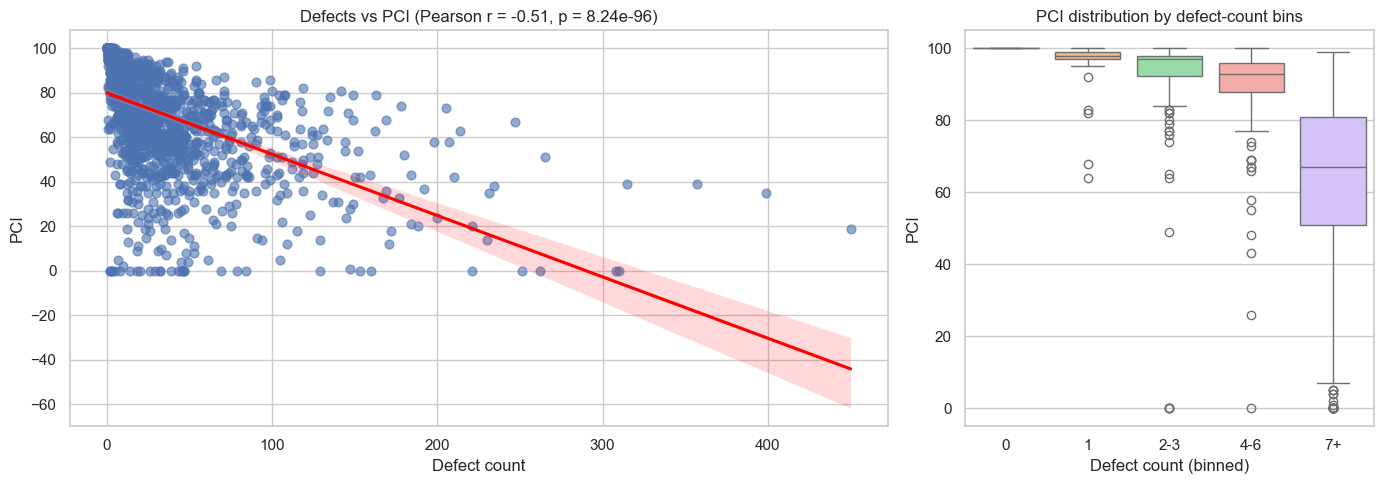

,defect_instances,pci,defect_bin
0,4,97.0,4-6
1,2,98.0,2-3
2,33,57.0,7+
3,144,58.0,7+
4,32,51.0,7+


In [21]:
# Visualization: defects vs PCI (scatter + PCI distribution by defect bins)
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid", context="notebook")

# --- Robustly find or build a working dataframe ---
# Preferred: a GeoDataFrame `road_gdf` with defect count and pci columns.
g = globals()
def_col_candidates = ["defect_instances", "defect_count", "num_defects", "defects"]
pci_col_candidates = ["pci", "PCI", "pavement_condition_index"]

df = None
if "road_gdf" in g:
    df = g["road_gdf"].copy()
else:
    # try to merge defect_df and pci_df if present
    if "defect_df" in g and "pci_df" in g:
        left = g["defect_df"].copy()
        right = g["pci_df"].copy()
        # try common join keys
        for key in ("segment_id", "road_id", "id"):
            if key in left.columns and key in right.columns:
                df = left.merge(right, on=key, how="outer")
                break
        if df is None:
            # fallback: outer join on index
            df = left.join(right, how="outer")
    else:
        raise RuntimeError("No `road_gdf` or (`defect_df` + `pci_df`) found in the notebook namespace.")

# find actual column names
def_col = next((c for c in def_col_candidates if c in df.columns), None)
pci_col = next((c for c in pci_col_candidates if c in df.columns), None)
if def_col is None or pci_col is None:
    raise RuntimeError(f"Couldn't find defect or PCI columns. Looked for {def_col_candidates} and {pci_col_candidates}. Found: {list(df.columns)}")

# prepare numeric columns
df = df[[def_col, pci_col]].dropna()
df[def_col] = pd.to_numeric(df[def_col], errors="coerce")
df[pci_col] = pd.to_numeric(df[pci_col], errors="coerce")
df = df.dropna()

# --- Scatter + regression plot ---
r, p = stats.pearsonr(df[def_col], df[pci_col]) if len(df) > 1 else (np.nan, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
sns.regplot(x=def_col, y=pci_col, data=df, scatter_kws={"alpha": 0.6, "s": 40}, line_kws={"color": "red"}, ax=ax)
ax.set_xlabel("Defect count")
ax.set_ylabel("PCI")
ax.set_title(f"Defects vs PCI (Pearson r = {r:.2f}, p = {p:.3g})")

# annotate a few extreme points
if len(df) <= 1000:
    for _, row in df.sort_values(by=def_col, ascending=False).head(5).iterrows():
        ax.annotate(int(row[def_col]), (row[def_col], row[pci_col]), textcoords="offset points", xytext=(5,2), fontsize=8)

# --- PCI distribution by defect-count bins ---
# create bins (customize as needed)
bins = [ -0.1, 0, 1, 3, 6, 1000 ]
labels = ["0", "1", "2-3", "4-6", "7+"]
df["defect_bin"] = pd.cut(df[def_col], bins=bins, labels=labels, include_lowest=True)

ax2 = axes[1]
order = labels
sns.boxplot(x="defect_bin", y=pci_col, data=df, order=order, palette="pastel", ax=ax2)
ax2.set_xlabel("Defect count (binned)")
ax2.set_ylabel("PCI")
ax2.set_title("PCI distribution by defect-count bins")
plt.tight_layout()
plt.show()

# --- Optional: Return df for further inspection ---
df_sample = df.sample(min(1000, len(df))).reset_index(drop=True)
df_sample.head()

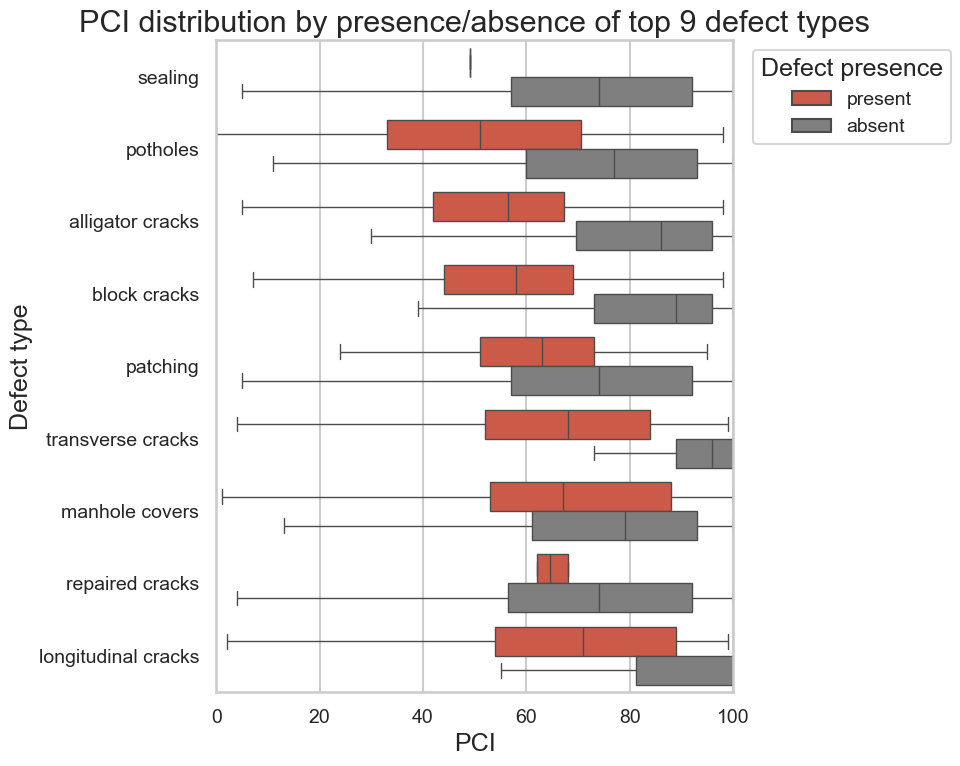

,defect_type,mean_pci_present,n_present,mean_pci_absent,n_absent,p_value
0,sealing,49.00,1,70.73,1466,NaN
1,potholes,49.82,191,73.84,1276,2.644289e-25
2,alligator cracks,53.10,504,79.93,963,6.795266e-93
3,block cracks,54.41,597,81.90,870,4.884500e-114
4,patching,58.31,13,70.82,1454,1.167580e-01
5,transverse cracks,65.37,1146,89.79,321,6.079767e-78
6,manhole covers,66.27,545,73.34,922,7.047174e-08
7,repaired cracks,67.38,8,70.73,1459,5.032746e-01
8,longitudinal cracks,68.40,1305,89.38,162,5.219491e-32


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

if 'road_gdf' not in globals():
    raise RuntimeError("`road_gdf` not found in the notebook namespace")

df = road_gdf.copy()
if 'defects' not in df.columns or 'pci' not in df.columns:
    raise RuntimeError("`defects` or `pci` column missing in `road_gdf`")

# normalize defect dicts and get totals
defect_dicts = df['defects'].apply(lambda d: d if isinstance(d, dict) else {})
type_totals = {}
for d in defect_dicts:
    for k, v in d.items():
        if isinstance(v, (int, float)) and v > 0:
            type_totals[k] = type_totals.get(k, 0) + v
if not type_totals:
    raise RuntimeError("No defect types found in `road_gdf.defects`")

# choose top defect types
top_n = 12
top_types = [t for t, _ in sorted(type_totals.items(), key=lambda x: x[1], reverse=True)[:top_n]]

# build long-form dataframe: one row per (segment, defect_type)
rows = []
for pci_val, dct in zip(df['pci'], defect_dicts):
    if pd.isna(pci_val):
        continue
    for dt in top_types:
        pres = 1 if (isinstance(dct.get(dt, 0), (int, float)) and dct.get(dt, 0) > 0) else 0
        rows.append({'defect_type': dt, 'presence': 'present' if pres else 'absent', 'pci': pci_val})
long = pd.DataFrame(rows)

# compute mean PCI for each defect type (use mean when present if available)
mean_present = long.groupby('defect_type').apply(
    lambda g: g.loc[g['presence'] == 'present', 'pci'].mean() if (g['presence'] == 'present').any() else g['pci'].mean()
)
order = mean_present.sort_values().index.tolist() 

# horizontal boxplot (defect types on y-axis)
plt.figure(figsize=(10, 8))
sns.set_context("talk", rc={
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
ax = sns.boxplot(y='defect_type', x='pci', hue='presence', data=long,
                 palette={'present':'#E24A33','absent':'#7F7F7F'},
                 order=order, showfliers=False)
ax.set_xlim(0, 100)
ax.set_xlabel('PCI')
ax.set_ylabel('Defect type')
ax.set_title(f'PCI distribution by presence/absence of top {len(top_types)} defect types')
ax.legend(title='Defect presence', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# summary stats sorted by the same order
stats_rows = []
for dt in order:
    grp = long[long['defect_type'] == dt].groupby('presence')['pci']
    present = grp.get_group('present') if 'present' in grp.groups else pd.Series(dtype=float)
    absent = grp.get_group('absent') if 'absent' in grp.groups else pd.Series(dtype=float)
    n_present, n_absent = len(present), len(absent)
    mean_p = present.mean() if n_present>0 else np.nan
    mean_a = absent.mean() if n_absent>0 else np.nan
    p_val = np.nan
    if n_present > 1 and n_absent > 1:
        _, p_val = stats.ttest_ind(present, absent, equal_var=False, nan_policy='omit')
    stats_rows.append({
        'defect_type': dt,
        'mean_pci_present': round(mean_p, 2) if not np.isnan(mean_p) else None,
        'n_present': int(n_present),
        'mean_pci_absent': round(mean_a, 2) if not np.isnan(mean_a) else None,
        'n_absent': int(n_absent),
        'p_value': float(p_val) if not np.isnan(p_val) else None
    })

stats_df = pd.DataFrame(stats_rows)
display(stats_df.reset_index(drop=True))

In [23]:
# === Maps: roadSegments (PCI) + locations (defect counts) ===
import folium
from folium.plugins import MarkerCluster
import branca.colormap as cm

# center map on data
try:
    center = [df_loc['lat'].mean(), df_loc['lon'].mean()]
except Exception:
    center = [loc_gdf.geometry.y.mean(), loc_gdf.geometry.x.mean()]

# --- Map 2: road segments colored by PCI ---
min_pci = float(road_gdf['pci'].min()) if 'pci' in road_gdf.columns and pd.notna(road_gdf['pci'].min()) else 0.0
max_pci = float(road_gdf['pci'].max()) if 'pci' in road_gdf.columns and pd.notna(road_gdf['pci'].max()) else 100.0
colormap = cm.LinearColormap(['red', 'orange', 'yellow', 'green'], vmin=min_pci, vmax=max_pci)

m1 = folium.Map(location=center, zoom_start=13)
folium.GeoJson(
    road_gdf.to_json(),
    name='roadSegments',
    style_function=lambda feat: {
        'color': colormap(feat['properties'].get('pci')) if feat['properties'].get('pci') is not None else '#808080',
        'weight': 3,
        'opacity': 0.8
    },
    tooltip=folium.GeoJsonTooltip(fields=['road_id', 'name', 'pci', 'length_km'])
).add_to(m1)
colormap.caption = 'PCI'
colormap.add_to(m1)
folium.LayerControl().add_to(m1)

display(m1)

### 1.2.5 Other potentially important (Layer A)

Road class

| ROADCLASS | # segments |
|---|---:|
| Residential | 1,305 |
| Major Arterial | 499 |
| Private | 70 |
| Highway | 59 |
| Ramp | 25 |
| Minor Arterial | 1 |
| Minor Collector | 1 |

Length

| Stat | Value |
|---|---:|
| Total network | 304.1 km |
| Mean segment | 155 m |
| Median segment | 116 m |
| Longest segment | 991 m |

Geometry

| Stat | Value |
|---|---:|
| Vertices per LineString (median) | 6 |
| Vertices per LineString (max) | 586 |

## 2 Rehab activities

In [24]:
from pathlib import Path
from openpyxl import load_workbook

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

workbook = Path("../data/relookingforroaddata (1)/PeachtreeCornersGA2022_ESA_5Yr_Rev2.xlsm")
ws = load_workbook(workbook, read_only=True, data_only=True)["Rehab Activities"]

columns = [
    "Pavetype",
    "Rehab Code",
    "Rehab Activity",
    "G1 Min PCI",
    "G1 Critical PCI",
    "G1 Max PCI",
    "G2 Min PCI",
    "G2 Critical PCI",
    "G2 Max PCI",
    "G3 Min PCI",
    "G3 Critical PCI",
    "G3 Max PCI",
    "Base Unit Rate ($/yd2)",
    "Minor Arterial Unit Rate ($/yd2)",
    "Major Collector Unit Rate ($/yd2)",
    "Minor Collector Unit Rate ($/yd2)",
    "Residential Unit Rate ($/yd2)",
    "FunCL 5 Unit Rate ($/yd2)",
    "FunCL 6 Unit Rate ($/yd2)",
    "Construction Activities Burden Included in Unit Rates (%)",
    "Agency Overheads Included in Unit Rates (%)",
    "Reset PCI",
]

rows = []
for r in range(12, ws.max_row + 1):
    values = [ws.cell(r, c).value for c in range(2, 24)]
    if not any(v not in (None, "") for v in values):
        continue
    rows.append(values)

rehab_df = pd.DataFrame(rows, columns=columns)

numeric_cols = [
    "Rehab Code",
    "G1 Min PCI", "G1 Critical PCI", "G1 Max PCI",
    "G2 Min PCI", "G2 Critical PCI", "G2 Max PCI",
    "G3 Min PCI", "G3 Critical PCI", "G3 Max PCI",
    "Base Unit Rate ($/yd2)",
    "Minor Arterial Unit Rate ($/yd2)",
    "Major Collector Unit Rate ($/yd2)",
    "Minor Collector Unit Rate ($/yd2)",
    "Residential Unit Rate ($/yd2)",
    "FunCL 5 Unit Rate ($/yd2)",
    "FunCL 6 Unit Rate ($/yd2)",
    "Construction Activities Burden Included in Unit Rates (%)",
    "Agency Overheads Included in Unit Rates (%)",
    "Reset PCI",
]
for col in numeric_cols:
    rehab_df[col] = pd.to_numeric(rehab_df[col], errors="coerce")

# rehab_df = rehab_df[rehab_df["Pavetype"].eq("Asphalt")].copy()

rate_col = "Base Unit Rate ($/yd2)"
group_specs = [
    ("Rehab Group 1", "G1 Min PCI", "G1 Max PCI"),
    ("Rehab Group 2", "G2 Min PCI", "G2 Max PCI"),
    ("Rehab Group 3", "G3 Min PCI", "G3 Max PCI"),
]

plot_rows = []
for group_name, min_col, max_col in group_specs:
    tmp = rehab_df[
        ["Pavetype", "Rehab Activity", "Rehab Code", min_col, max_col, rate_col]
    ].dropna(subset=[min_col, max_col, rate_col]).copy()

    tmp = tmp[tmp[max_col] >= tmp[min_col]]

    for _, row in tmp.iterrows():
        lo = int(round(row[min_col]))
        hi = int(round(row[max_col]))
        for pci in range(lo, hi + 1):
            plot_rows.append(
                {
                    "pci": pci,
                    "unit_rate": float(row[rate_col]),
                    "rehab_group": group_name,
                    "activity": row["Rehab Activity"],
                    "code": int(row["Rehab Code"]) if pd.notna(row["Rehab Code"]) else None,
                    "pavetype": row["Pavetype"]
                }
            )

plot_df = pd.DataFrame(plot_rows)